In [425]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

import sys
sys.path.insert(1, r'C:\Users\tomaz.bregar\Desktop\PhD\pyFBS')

import numpy as np

from pyfbs.io import Impacts,Channels,Sensors
from pyfbs.vpt import VPT
import os


path_list = os.path.abspath('__file__').split(os.sep)
script_directory = path_list[0:len(path_list)-2]

example_xlsx = "/".join(script_directory) + "/" + "data/test_geometry.xlsx"
example_xlsx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'C:/Users/tomaz.bregar/Desktop/PhD/pyFBS/data/test_geometry.xlsx'

In [465]:
def R_matrix_U(pos):
    """
    Return the R matrix according to the position.
    """
    rx,ry,rz = pos[0],pos[1],pos[2]
    
    return np.asarray([[1,0,0,0,rz,-ry],
                       [0,1,0,-rz,0,rx],
                       [0,0,1,ry,-rx,0]])

        

def R_matrix_F(pos):
    """
    Return the R matrix according to the position.
    """
    rx,ry,rz = pos[0],pos[1],pos[2]
    
    return np.asarray([[1,0,0],
                       [0,1,0],
                       [0,0,1],
                       [0,-rz,ry],
                       [rz,0,-rx],
                       [ry,-rx,0]])

In [467]:
gg = VPT(example_xlsx)

In [468]:
def find_overlap_ch(channelsA,channelsB):
    _group_ch = []
    for _ch in channelsA:
        _group_ch.append(_ch.Grouping)

    _group_ch = np.asarray(_group_ch)


    _group_chVP = []
    for _ch in channelsB:
        _group_chVP.append(_ch.Grouping)

    _group_chVP = np.asarray(_group_chVP)


    _overlap = []
    for a in np.unique(_group_chVP):
        _overlap.append(np.where(_group_ch == a))
    
    mask = np.isin(_group_ch,np.unique(_group_chVP),invert = True).astype(int)
    
    return _overlap, np.unique(_group_chVP,return_index=True),mask




In [474]:
ov_u,_vps,mask_u = find_overlap_ch(gg.Channels,gg.Virtual_Channels)
ov_f,_vps,mask_f = find_overlap_ch(gg.RefChannels,gg.Virtual_RefChannels)

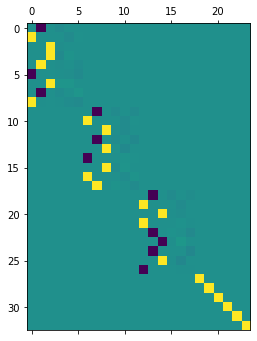

In [497]:
"""
Function to define the IDM U! 
"""
R_all = []
# iterates through all unique virtual points (through grouping)
for i in range(len(ov_u)):
    
    # gets the unique VP position
    _posVP = np.asarray(gg.Virtual_Channels[_vps[1][i]].Position)
    
    # gets the current positions
    ov_c = ov_u[i]
    r = np.zeros((len(ov_c[0]),6))
    
    for i,ch in enumerate(ov_c[0]):
        _pos = np.asarray(gg.Channels[ch].Position)
        _dir = np.asarray([gg.Channels[ch].Direction])
        _group = gg.Channels[ch].Grouping
        
        r[i,:] = _dir@R_matrix(_posVP - _pos)

    R_all.append(r)
    
Ru = block_diag(*R_all,np.eye(len(np.where(mask_u != 0)[0])))
plt.matshow(Ru)

Wu = np.eye(np.max(Ru.shape))
Tu = np.linalg.pinv(Ru.T@Wu@Ru)@Ru.T@Wu
Fu = Ru@Tu


(18, 27)


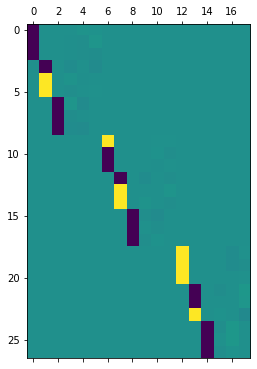

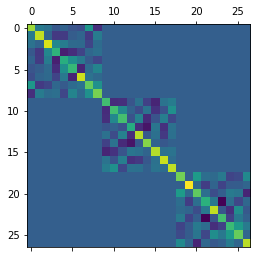

In [520]:
"""
Function to define the IDM F!
"""

R_all = []
# iterates through all unique virtual points (through grouping)
for i in range(len(ov_f)):
    # gets the unique VP position
    _posVP = np.asarray(gg.Virtual_Channels[_vps[1][i]].Position)
    
    # gets the current positions
    ov_c = ov_f[i]
    r = np.zeros((len(ov_c[0]),6))
    
    for i,ch in enumerate(ov_c[0]):
        _pos = np.asarray(gg.RefChannels[ch].Position)
        _dir = np.asarray([gg.RefChannels[ch].Direction])
        _group = gg.RefChannels[ch].Grouping
        
        r[i,:] = (R_matrix_F(_posVP - _pos)@(_dir.T)).reshape(-1)
        
    R_all.append(r)
    
    
Rf = block_diag(*R_all,np.eye(len(np.where(mask_f != 0)[0])))
plt.matshow(Rf)
print(Rf.T.shape)# = Rf.T

Wf = np.eye(np.max(Rf.shape))
Tf = Wf@Rf@np.linalg.pinv(Rf.T@Wf@Rf)
Ff = Rf@Tf.T

plt.matshow(Ff)